<a href="https://colab.research.google.com/github/GrzegorzK121/fastapi-rtls-integration/blob/main/Test_RTLS_Kaczorek_22_04_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Pobieranie i przetwarzanie danych z chmury...


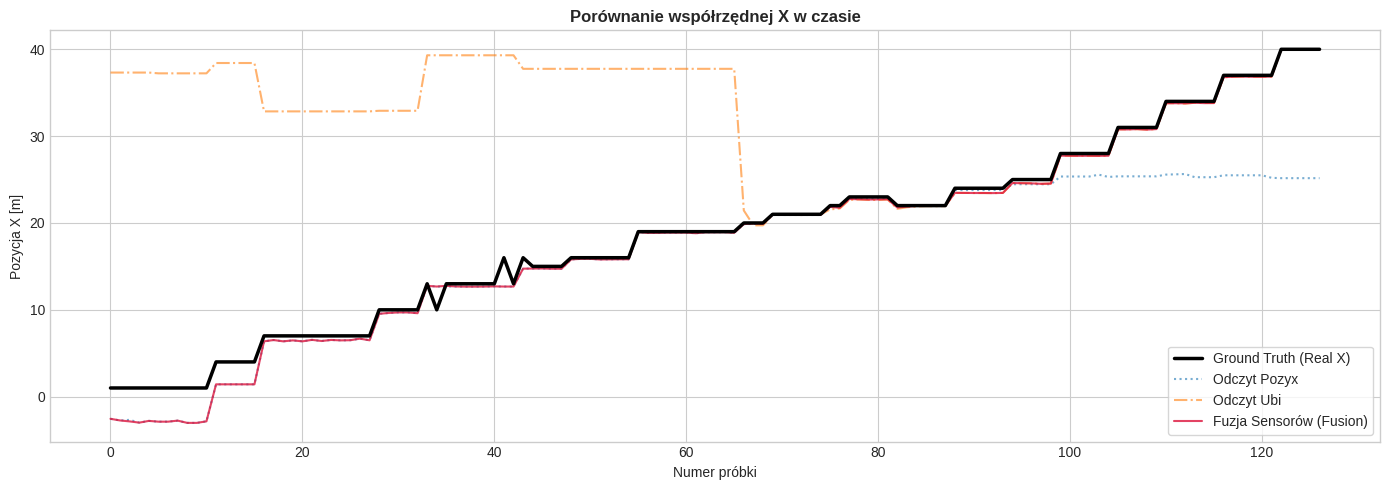

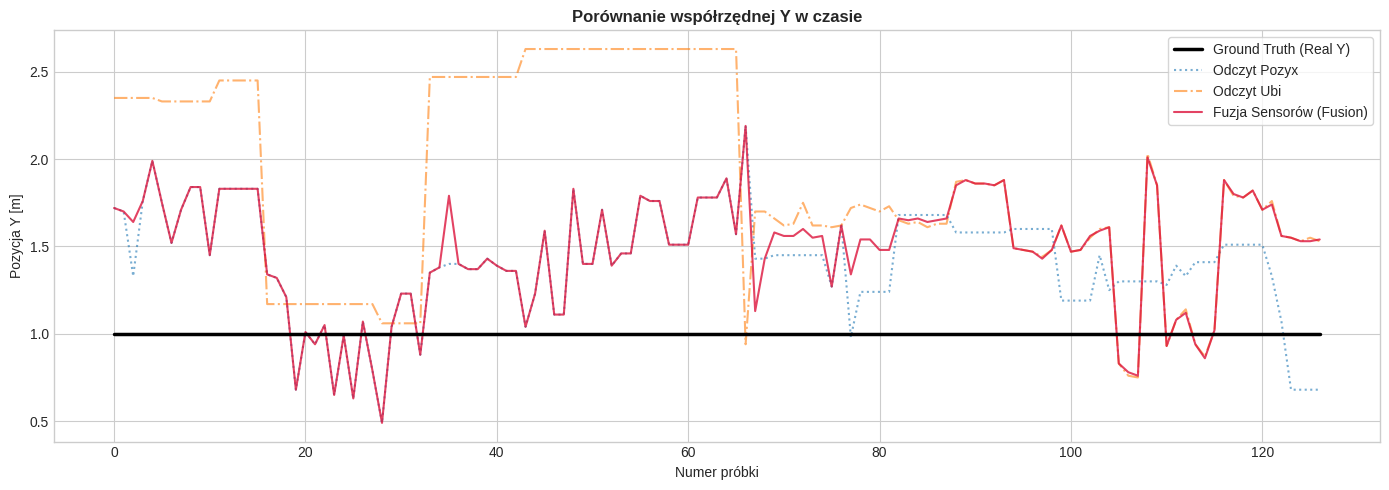

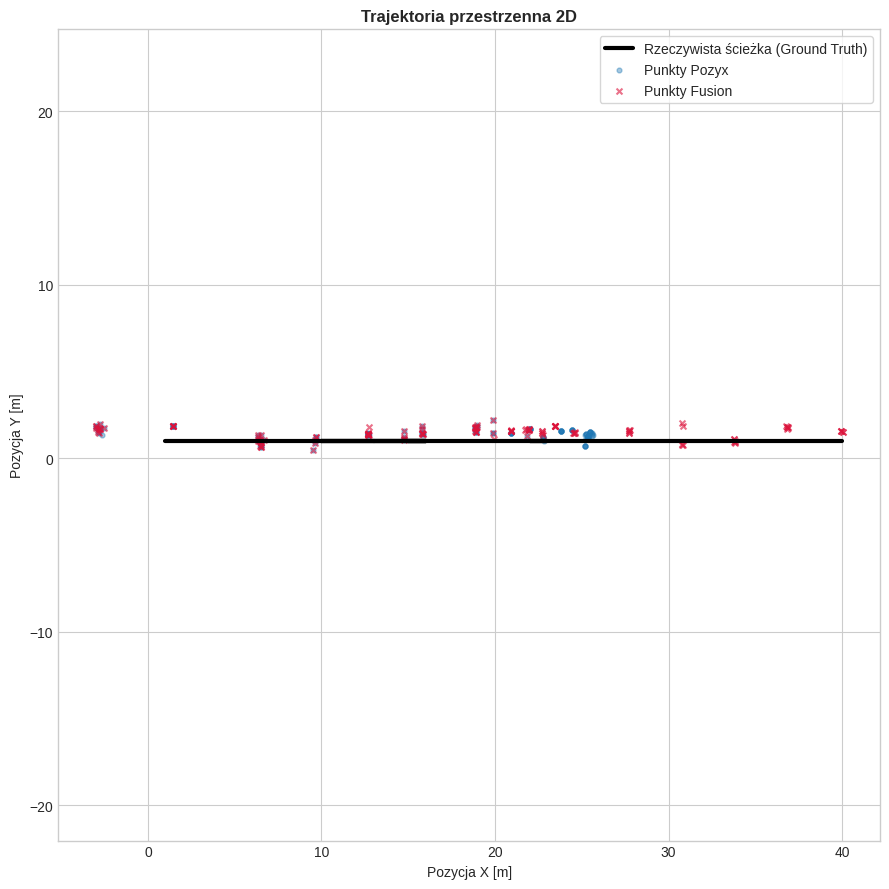


[SUKCES] Wykresy zostały wygenerowane bezpośrednio z danych chmurowych!


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

URL_DO_DANYCH = "Snap_22_04_GroundTruth.csv"

print("Pobieranie i przetwarzanie danych z chmury...")

# 2. Wczytanie danych bezpośrednio z adresu URL
df = pd.read_csv(URL_DO_DANYCH, sep=';')

# 3. Konwersja kolumn na format numeryczny i czyszczenie danych (TIMEOUT -> NaN)
cols_to_convert = ['Real_x', 'Real_y', 'X_Pozyx', 'X_Ubi', 'X_Fusion', 'Y_Pozyx', 'Y_Ubi', 'Y_Fusion']
for col in cols_to_convert:
    if col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.replace(',', '.')
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Ustawienie estetycznego stylu wykresów
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')


# WYKRES 1: Współrzędna X w czasie

plt.figure(figsize=(14, 5))
if 'Real_x' in df.columns:
    plt.plot(df.index, df['Real_x'], label='Ground Truth (Real X)', color='black', linewidth=2.5, zorder=5)
if 'X_Pozyx' in df.columns:
    plt.plot(df.index, df['X_Pozyx'], label='Odczyt Pozyx', alpha=0.6, linestyle=':')
if 'X_Ubi' in df.columns:
    plt.plot(df.index, df['X_Ubi'], label='Odczyt Ubi', alpha=0.6, linestyle='-.')
if 'X_Fusion' in df.columns:
    plt.plot(df.index, df['X_Fusion'], label='Fuzja Sensorów (Fusion)', alpha=0.8, color='crimson', linewidth=1.5)

plt.title('Porównanie współrzędnej X w czasie', fontsize=12, fontweight='bold')
plt.xlabel('Numer próbki')
plt.ylabel('Pozycja X [m]')
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig('wykres_X.png', dpi=300)
plt.show()

# WYKRES 2: Współrzędna Y w czasie

plt.figure(figsize=(14, 5))
if 'Real_y' in df.columns:
    plt.plot(df.index, df['Real_y'], label='Ground Truth (Real Y)', color='black', linewidth=2.5, zorder=5)
if 'Y_Pozyx' in df.columns:
    plt.plot(df.index, df['Y_Pozyx'], label='Odczyt Pozyx', alpha=0.6, linestyle=':')
if 'Y_Ubi' in df.columns:
    plt.plot(df.index, df['Y_Ubi'], label='Odczyt Ubi', alpha=0.6, linestyle='-.')
if 'Y_Fusion' in df.columns:
    plt.plot(df.index, df['Y_Fusion'], label='Fuzja Sensorów (Fusion)', alpha=0.8, color='crimson', linewidth=1.5)

plt.title('Porównanie współrzędnej Y w czasie', fontsize=12, fontweight='bold')
plt.xlabel('Numer próbki')
plt.ylabel('Pozycja Y [m]')
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
plt.savefig('wykres_Y.png', dpi=300)
plt.show()


# WYKRES 3: Trajektoria 2D (Widok z góry)

plt.figure(figsize=(9, 9))
if 'Real_x' in df.columns and 'Real_y' in df.columns:
    plt.plot(df['Real_x'], df['Real_y'], label='Rzeczywista ścieżka (Ground Truth)', color='black', linewidth=3, zorder=10)
if 'X_Pozyx' in df.columns and 'Y_Pozyx' in df.columns:
    plt.scatter(df['X_Pozyx'], df['Y_Pozyx'], label='Punkty Pozyx', alpha=0.4, s=12, marker='o')
if 'X_Fusion' in df.columns and 'Y_Fusion' in df.columns:
    plt.scatter(df['X_Fusion'], df['Y_Fusion'], label='Punkty Fusion', alpha=0.6, s=18, marker='x', color='crimson')

plt.title('Trajektoria przestrzenna 2D', fontsize=12, fontweight='bold')
plt.xlabel('Pozycja X [m]')
plt.ylabel('Pozycja Y [m]')
plt.legend(frameon=True, facecolor='white')
plt.axis('equal')
plt.tight_layout()
plt.savefig('trajektoria_2D.png', dpi=300)
plt.show()

print("\n[SUKCES] Wykresy zostały wygenerowane bezpośrednio z danych chmurowych!")

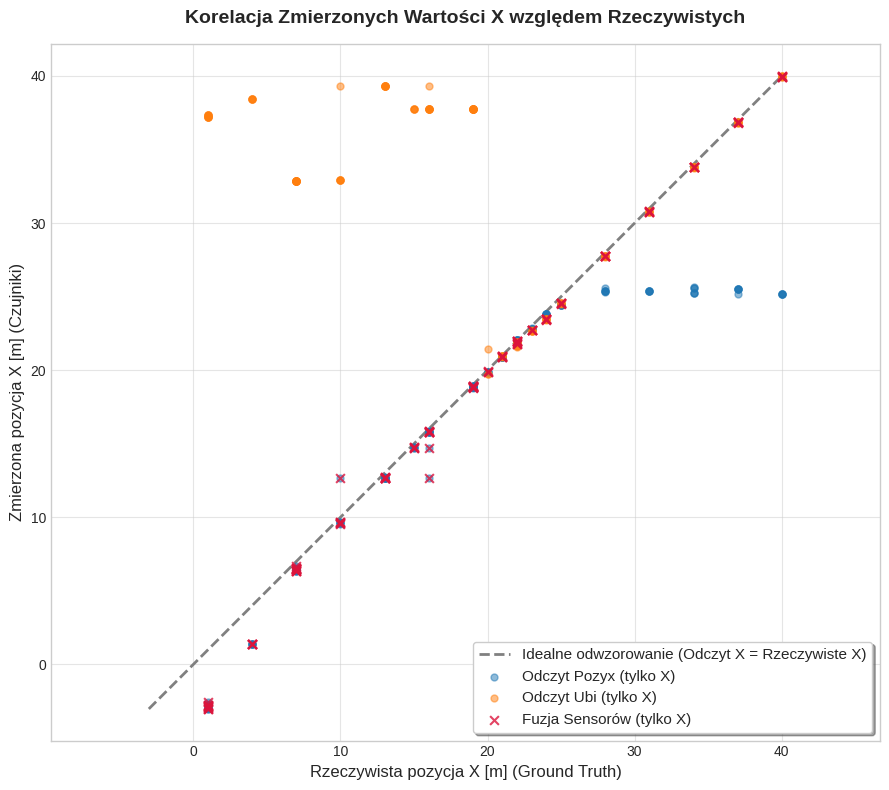

In [8]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.figure(figsize=(9, 8))

# Rysujemy korelacje TYLKO dla fizycznej osi X
if 'Real_x' in df.columns:
    min_x = min(df['Real_x'].dropna().min(), df[['X_Pozyx', 'X_Ubi', 'X_Fusion']].dropna().values.min())
    max_x = max(df['Real_x'].dropna().max(), df[['X_Pozyx', 'X_Ubi', 'X_Fusion']].dropna().values.max())

    plt.plot([min_x, max_x], [min_x, max_x], color='gray', linestyle='--', linewidth=2, label='Idealne odwzorowanie (Odczyt X = Rzeczywiste X)', zorder=1)

    if 'X_Pozyx' in df.columns:
        plt.scatter(df['Real_x'], df['X_Pozyx'], alpha=0.5, s=25, label='Odczyt Pozyx (tylko X)', color='#1f77b4')
    if 'X_Ubi' in df.columns:
        plt.scatter(df['Real_x'], df['X_Ubi'], alpha=0.5, s=25, label='Odczyt Ubi (tylko X)', color='#ff7f0e')
    if 'X_Fusion' in df.columns:
        plt.scatter(df['Real_x'], df['X_Fusion'], alpha=0.8, s=40, color='crimson', marker='x', label='Fuzja Sensorów (tylko X)', zorder=5)

plt.title('Korelacja Zmierzonych Wartości X względem Rzeczywistych', fontsize=14, fontweight='bold', pad=15)

# Jasne nazwanie osi rysunku, żeby recenzent pracy nie miał wątpliwości!
plt.xlabel('Rzeczywista pozycja X [m] (Ground Truth)', fontsize=12)
plt.ylabel('Zmierzona pozycja X [m] (Czujniki)', fontsize=12)

plt.legend(frameon=True, facecolor='white', shadow=True, fontsize=11)
plt.grid(True, alpha=0.5)
plt.axis('equal')
plt.tight_layout()
plt.show()

**Tabela z błędami  MAE**


In [10]:
# Obliczanie błędów dla osi X
errors = pd.DataFrame({
    'System': ['Pozyx', 'Ubi', 'Fusion'],
    'MAE [m]': [
        (df['Real_x'] - df['X_Pozyx']).abs().mean(),
        (df['Real_x'] - df['X_Ubi']).abs().mean(),
        (df['Real_x'] - df['X_Fusion']).abs().mean()
    ]
})
print("Podsumowanie dokładności (średni błąd MAE):")
print(errors)

Podsumowanie dokładności (średni błąd MAE):
   System    MAE [m]
0   Pozyx   2.530394
1     Ubi  13.750709
2  Fusion   0.706614


3. Analiza dostępności danych (Availability)

In [11]:
availability = {
    'Pozyx': df['X_Pozyx'].notna().mean() * 100,
    'Ubi': df['X_Ubi'].notna().mean() * 100,
    'Fusion': df['X_Fusion'].notna().mean() * 100
}
print("Dostępność danych w procentach:")
for sys, val in availability.items():
    print(f"{sys}: {val:.2f}%")

Dostępność danych w procentach:
Pozyx: 100.00%
Ubi: 100.00%
Fusion: 100.00%
